# T2 AC Stark Shift

Coupler spectroscopy probed via the manipulate channel.
Sequence: prep M1 in Fock |1>, sweep a const probe on the manipulate DAC,
swap |1> back to qubit |e> (f0-g1 pi + e0-f0 pi), then measure.

# Import

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from copy import deepcopy

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base

from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

# Initialize database and config manager
db = get_database()
config_dir = 'D:/python/multimode_expts/configs'
config_manager = ConfigVersionManager(config_dir)

# Initialize job client (handle submitting and waiting for jobs)
client = JobClient()

# Check server health
health = client.health_check()
print(f"Server status: {health['status']}")
print(f"Pending jobs: {health['pending_jobs']}")

user = "seb"
print("Welcome", user)


station = MultimodeStation(
    user=user,
    experiment_name="260420_T2_AC_stark",
)

active_reset_dict = {
    'active_reset': True,
    'ef_reset': True,
    'storage_reset': False,
    'coupler_reset': False,
    'pre_selection_reset': True,
    'man_reset': False,
    'use_qubit_man_reset': True,
    'pre_selection_parity': True,
}

USE_QUEUE = True
mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soc)

Importing all classes from  D:\python\multimode_expts\experiments\dual_rail
Importing all classes from  D:\python\multimode_expts\experiments\qsim
Importing all classes from  D:\python\multimode_expts\experiments\qubit_cavity
Importing all classes from  D:\python\multimode_expts\experiments\single_qubit
Skipped top-level files ['characterization_runner.py', 'dataset.py', 'MM_base.py', 'MM_dual_rail_base.py', 'MM_rb_base.py', 'mock_hardware.py', 'sequential_experiment.py', 'sequential_experiment_classes.py', 'station.py', 'sweep_runner.py']
Server status: healthy
Pending jobs: 1
Welcome seb
[STATION] Using main hardware_config version: CFG-HW-20260421-00002
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using main man1_storage_swap version: CFG-M1-20260420-00027
[STATION] Using main floquet_storage_swap version: CFG-FL-20260223-00023
Data, plots, logs will be stored in: D:\experiments\260420_T2_AC_stark
Hardware configs will be read from D:\python\multi

# Coupler spectroscopy (pulse probe via manipulate channel)

In [7]:
# ============================================
# Pulse-probe coupler spectroscopy
# prep M1 |1>  ->  swept const probe on man_ch  ->  swap |1> -> |e>  ->  readout
# ============================================

# 1. Defaults
coupler_spec_defaults = AttrDict(dict(
    # Frequency sweep (absolute MHz; manipulate DAC has no mixer)
    start=4000.0,        # MHz
    step=0.5,            # MHz
    expts=201,           # number of points -> spans 4000..4100 MHz
    # Probe pulse
    length=5.0,          # us (const pulse)
    gain=500,            # DAC units
    # Averaging
    reps=200,
    rounds=1,
    # Mode / qubit selection
    qubits=[0],
    man_mode_no=1,       # manipulate mode used for prep + swap-out
    # Optional user prepulse (gate-list format consumed by custom_pulse)
    coupler_f=False,  # whether to apply a coupler pulse at the start of the sequence (for testing)
    prepulse=False,
    pre_sweep_pulse=None,
    # Reset
    active_reset=False,
))


# 2. Optional postprocessor
def coupler_spec_postproc(station, expt):
    """Fit + display the spectroscopy trace."""
    expt.analyze(fit=True)
    expt.display(fit=True)
    return None


# 3. Runner
coupler_spec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.PulseProbeCouplerSpectroscopyExperiment,
    default_expt_cfg=coupler_spec_defaults,
    postprocessor=coupler_spec_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

In [8]:
f_start = 4050
f_stop = 4110
expts = 100
step = (f_stop - f_start) / (expts - 1)

In [9]:
coupler_pulses = {
    'pi_ge': {
        'freq': [4094.092],
        'length': [.15],
        'gain': [35000],
        # 'gain': [1000],
        'type': ['const']
  }
  }

station.hardware_cfg.device.coupler.pulses = coupler_pulses

Job submitted: JOB-20260421-00280 (queue position: 1)

[0.1s] Job JOB-20260421-00280: pending

[92.8s] Job JOB-20260421-00280: running
[WORKER] Loading PulseProbeCouplerSpectroscopyExperiment from experiments.single_qubit.pulse_probe_coupler_spectroscopy
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260421-00280_PulseProbeCouplerSpectroscopyExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 94%|████████████████████████████████▉  | 37674/40000 [01:34<00:05, 399.02it/s]
[196.8s] Job JOB-20260421-00280: completed
100%|███████████████████████████████████| 40000/40000 [01:40<00:00, 399.04it/s]
Saving D:\experiments\260420_T2_AC_stark\data\JOB-20260421-00280_PulseProbeCouplerSpectroscopyExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260420_T2_AC_stark\expt_objs\JOB-20260421-00280_expt.pkl

Job completed! Data: D:\experiments\260420_T2_AC_stark\da

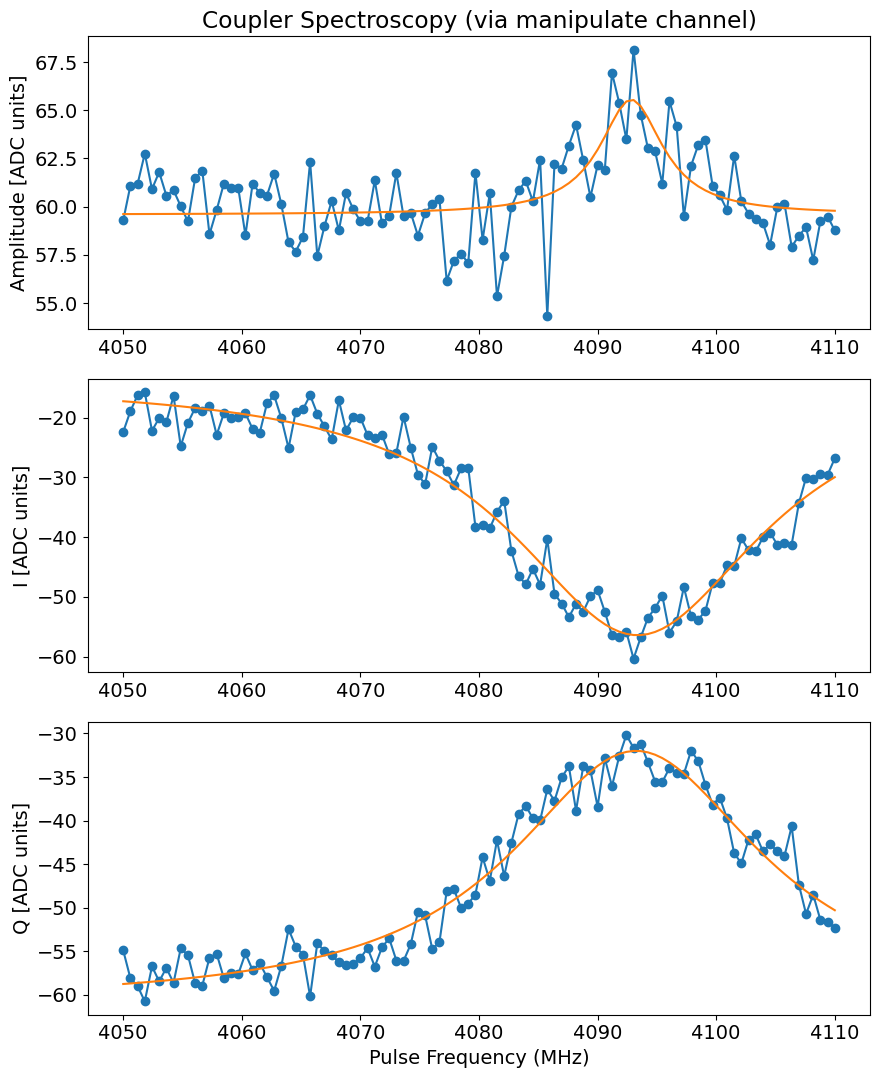

Found peak in amps at [MHz] 4092.8356223834057, HWHM 3.2327807183698787
Found peak in I at [MHz] 4093.367350709063, HWHM 13.030915874572237
Found peak in Q at [MHz] 4093.2468723420766, HWHM 12.899676167222763


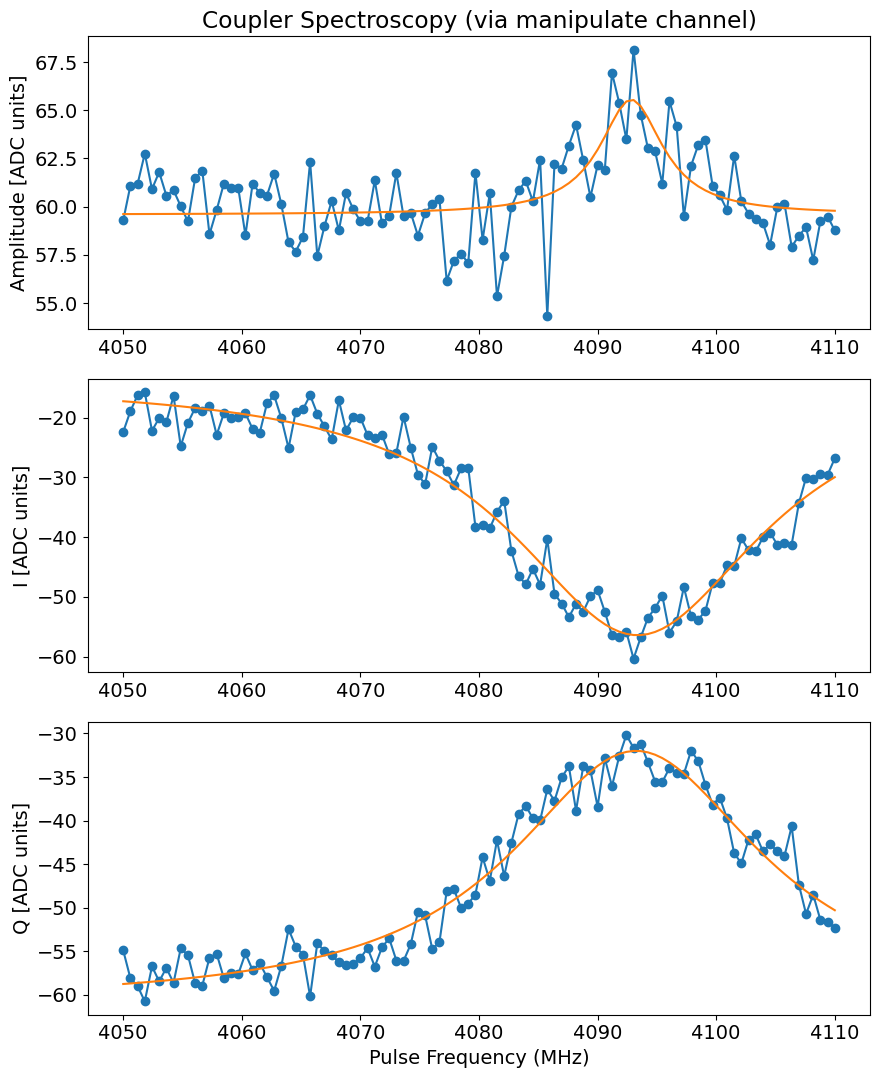

In [11]:
# 4. Execute
coupler_spec_expt = coupler_spec_runner.execute(
    start=f_start,
    step=step,
    expts=expts,
    length=2,
    gain=35000,
    reps=400,
    rounds=1,
    coupler_f=False,
    go_kwargs=dict(analyze=False, display=False),
    # **active_reset_dict,
)

# If using queue, analyze/display manually
if USE_QUEUE:
    coupler_spec_expt.analyze(fit=True)
    coupler_spec_expt.display(fit=True)

In [12]:
f_coupler = coupler_spec_expt.data['fit_avgi'][2]
print(f"Coupler frequency from spectroscopy: {f_coupler:.3f} MHz")

Coupler frequency from spectroscopy: 4093.367 MHz


# 2D sweep: coupler spectrum vs. Yoko-coupler DC current

Outer sweep is the Yoko-coupler current. We mirror the JPA-calibration pattern
from `single_qubit_autocalibrate_v2.ipynb`: a notebook-side loop over currents,
and inside the loop each point is submitted as a queued job via
`CharacterizationRunner.run()` (so no `run_local`). Data from each returned
child experiment is accumulated into a manually-built mother experiment for
2D plotting / saving.

Note: `worker.py` already auto-ramps `station.yoko_coupler` to
`cfg.expt.coupler_current` before each job, so passing `coupler_current=...`
to `runner.run()` is enough — no notebook-side ramp needed.

In [14]:
def do_coupler_current_sweep(
    station,
    sweep_start=0.0,        # mA
    sweep_stop=2.0,         # mA
    sweep_npts=11,
    live_plot=True,
    **kwargs,  # override coupler_spec_defaults (start, step, expts, gain, length, reps, ...)
):
    """
    Sweep Yoko-coupler current and run pulse-probe coupler spectroscopy at each point.

    Mirrors do_jpa_current_sweep: queue-based per-point jobs via CharacterizationRunner.run(),
    accumulated into a manually-built mother HDF5.

    Args:
        station: MultimodeStation instance.
        sweep_start, sweep_stop: current range [mA].
        sweep_npts: number of current points.
        live_plot: if True, update 2D plot after each point.
        **kwargs: override any coupler_spec_defaults (inner-sweep params, gain, etc.).

    Returns:
        Mother experiment object with 2D data saved to HDF5.
    """
    from IPython.display import clear_output

    # Merge 1D defaults with user overrides; these become the per-point expt cfg.
    expt_cfg = AttrDict(deepcopy(dict(coupler_spec_defaults)))
    expt_cfg.update(kwargs)

    current_vals_mA = np.linspace(sweep_start, sweep_stop, sweep_npts)

    # Safety: worker asserts |coupler_current| < 5 mA.
    assert np.max(np.abs(current_vals_mA)) < 1.0, \
        f"Requested current {np.max(np.abs(current_vals_mA)):.3f} mA exceeds 1 mA safety."

    # Per-point runner (queue mode).
    runner = CharacterizationRunner(
        station=station,
        ExptClass=meas.PulseProbeCouplerSpectroscopyExperiment,
        default_expt_cfg=expt_cfg,
        job_client=client,
    )

    # Mother experiment to accumulate 2D data + save to its own HDF5.
    mother_expt = meas.PulseProbeCouplerSpectroscopyExperiment(
        soccfg=station.soc,
        path=station.data_path,
        prefix='PulseProbeCouplerSpectroscopy_coupler_current_sweep',
        config_file=station.hardware_config_file,
    )
    mother_expt.cfg = AttrDict(deepcopy(station.hardware_cfg))
    mother_expt.cfg.expt = expt_cfg
    mother_expt.data = {'coupler_current_sweep_mA': []}

    print(f'Coupler current sweep: {sweep_start} to {sweep_stop} mA ({sweep_npts} pts)')
    print(f'  File: {mother_expt.fname}')

    for idx, i_mA in enumerate(current_vals_mA):
        print(f'  [{idx+1}/{len(current_vals_mA)}] coupler current = {i_mA:.4f} mA')

        # Submit one queued job. Worker ramps yoko_coupler to coupler_current (in A).
        expt = runner.run(
            postprocess=False,
            coupler_current=float(i_mA * 1e-3),  # A
        )

        # Accumulate per-point 1D results.
        mother_expt.data['coupler_current_sweep_mA'].append(i_mA)
        for key, val in expt.data.items():
            if key not in mother_expt.data:
                mother_expt.data[key] = []
            mother_expt.data[key].append(val)

        # Live 2D plot after the second point.
        if live_plot and len(mother_expt.data['coupler_current_sweep_mA']) > 1:
            clear_output(wait=True)
            plt.close('all')
            currents_so_far = np.asarray(mother_expt.data['coupler_current_sweep_mA'])
            freqs = np.asarray(mother_expt.data['xpts'][0])
            amps = np.asarray(mother_expt.data['avgi'])  # 'i' or 'amps' depending on postproc
            fig, ax = plt.subplots(figsize=(9, 5))
            pcm = ax.pcolormesh(freqs, currents_so_far, amps, shading='auto', cmap='viridis')
            ax.set_xlabel('Probe frequency [MHz]')
            ax.set_ylabel('Yoko-coupler current [mA]')
            ax.set_title('Coupler spectroscopy vs. DC flux (live)')
            fig.colorbar(pcm, ax=ax, label='|I + iQ|')
            plt.tight_layout()
            plt.show()

    # Freeze lists into numpy arrays and save.
    mother_expt.data = {k: np.array(v) for k, v in mother_expt.data.items()}
    mother_expt.save_data()
    print(f'Complete. Saved to {mother_expt.fname}')

    return mother_expt

In [48]:
f_start = 3800
f_stop = 4200
expts = 201
step = (f_stop - f_start) / (expts - 1)

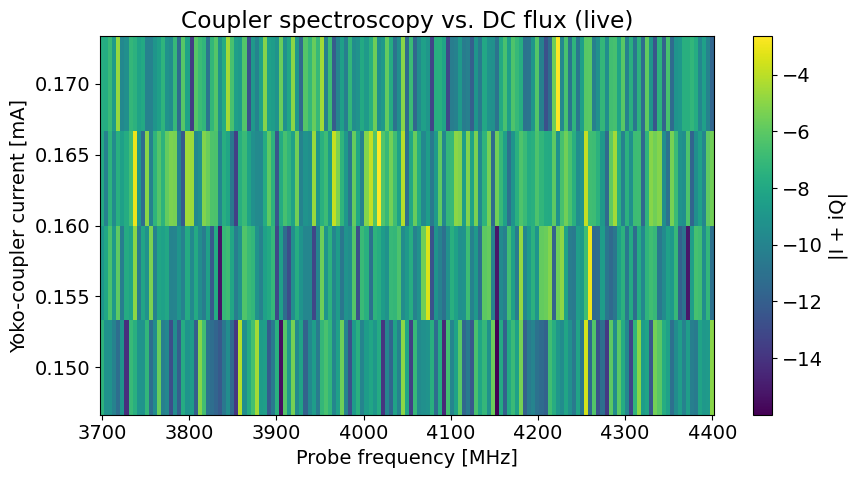

  [5/31] coupler current = 0.1767 mA
Job submitted: JOB-20260420-00411 (queue position: 1)

[0.1s] Job JOB-20260420-00411: pending

[2.1s] Job JOB-20260420-00411: running
[WORKER] Loading PulseProbeCouplerSpectroscopyExperiment from experiments.single_qubit.pulse_probe_coupler_spectroscopy
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260420-00411_PulseProbeCouplerSpectroscopyExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.17666666666666667mA according to expt.cfg...
[WORKER] Done setting coupler current
  5%|█▉                                  | 1638/30200 [00:04<01:11, 398.06it/s]

In [ ]:
# Run the 2D sweep (queue-based, per-point)
coupler_spec_2d = do_coupler_current_sweep(
    station,
    sweep_start=0.25,     # mA
    sweep_stop=0.35,      # mA
    sweep_npts=21,
    live_plot=True,
    # Inner-spectroscopy overrides (optional):
    start=f_start, step=step, expts=expts,
    gain=5000, length=5.0,
    # reps=200, rounds=1,
    # man_mode_no=1,
)

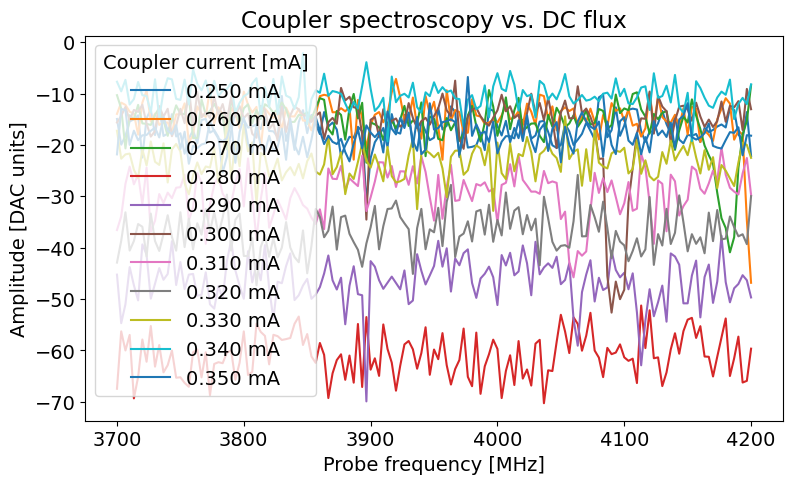

In [47]:
fig, ax = plt.subplots(figsize=(9, 5))
for idx, c in enumerate(coupler_spec_2d.data['coupler_current_sweep_mA']):
    freqs = coupler_spec_2d.data['xpts'][idx]
    amps = coupler_spec_2d.data['avgi'][idx]  # 'i' or 'amps' depending on postproc
    ax.plot(freqs, amps, label=f'{c:.3f} mA')
ax.set_xlabel('Probe frequency [MHz]')
ax.set_ylabel('Amplitude [DAC units]')
ax.set_title('Coupler spectroscopy vs. DC flux')
ax.legend(title='Coupler current [mA]')

# Coupler amplitude Rabi (via manipulate channel)

Prep M1 in Fock |1>, play a gaussian pulse on the manipulate DAC at a fixed
drive frequency with swept gain, swap |1> back to qubit |e>, then measure.

`freq` and `sigma` default to `cfg.device.coupler.pulses.hpi` once that entry
is snapshotted into the hardware config. Until then, pass them explicitly in
`cfg.expt` (as below) to bypass the hardware-config lookup.

In [2]:
# ============================================
# Coupler amplitude Rabi
# prep M1 |1>  ->  gauss pulse on man_ch (fixed freq, swept gain)  ->  swap |1> -> |e>  ->  readout
# ============================================

# 1. Defaults
coupler_rabi_defaults = AttrDict(dict(
    # Gain sweep [DAC units]
    start=0,
    step=200,
    expts=51,           # spans 0 .. 10000 DAC
    # Pulse envelope
    pulse_type='const', # 'gauss' (uses sigma) or 'const' (uses length)
    # Pulse params (override cfg.device.coupler.pulses.hpi once that entry exists)
    freq=4100.0,        # MHz
    length=5.0,         # us - flat const pulse duration
    # Averaging
    reps=200,
    rounds=1,
    # Mode / qubit selection
    qubits=[0],
    man_mode_no=1,
    # Optional user prepulse
    prepulse=False,
    pre_sweep_pulse=None,
    # Reset
    active_reset=False,
))



# 2. Optional postprocessor
def coupler_rabi_postproc(station, expt):
    """Fit + display the Rabi trace."""
    expt.analyze(fit=True)
    expt.display(fit=True)
    return None


# 3. Runner
coupler_rabi_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.AmplitudeRabiCouplerExperiment,
    default_expt_cfg=coupler_rabi_defaults,
    postprocessor=coupler_rabi_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

Job submitted: JOB-20260421-00325 (queue position: 2)

[0.1s] Job JOB-20260421-00325: pending

[90.8s] Job JOB-20260421-00325: running
[WORKER] Loading AmplitudeRabiCouplerExperiment from experiments.single_qubit.amplitude_rabi_coupler
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260421-00325_AmplitudeRabiCouplerExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 97%|██████████████████████████████████ | 39312/40400 [01:38<00:02, 399.31it/s]
[198.2s] Job JOB-20260421-00325: completed
100%|███████████████████████████████████| 40400/40400 [01:41<00:00, 399.30it/s]
Saving D:\experiments\260420_T2_AC_stark\data\JOB-20260421-00325_AmplitudeRabiCouplerExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260420_T2_AC_stark\expt_objs\JOB-20260421-00325_expt.pkl

Job completed! Data: D:\experiments\260420_T2_AC_stark\data\JOB-20260421-00325_AmplitudeRabiCo

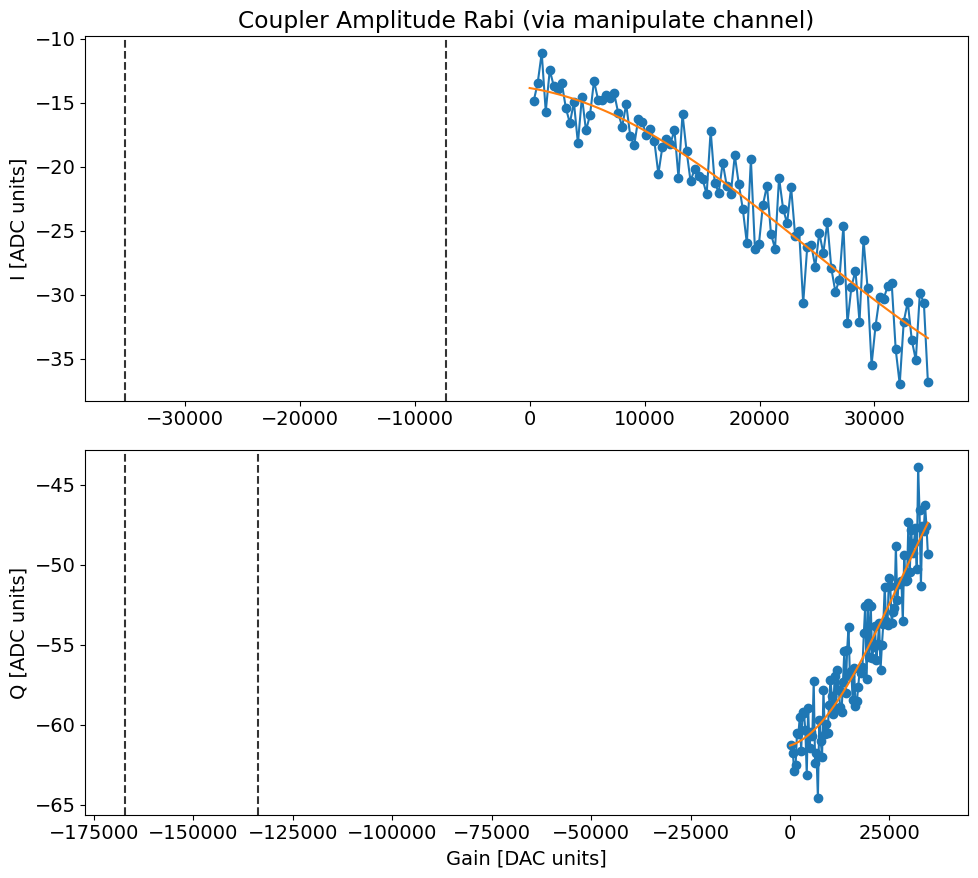

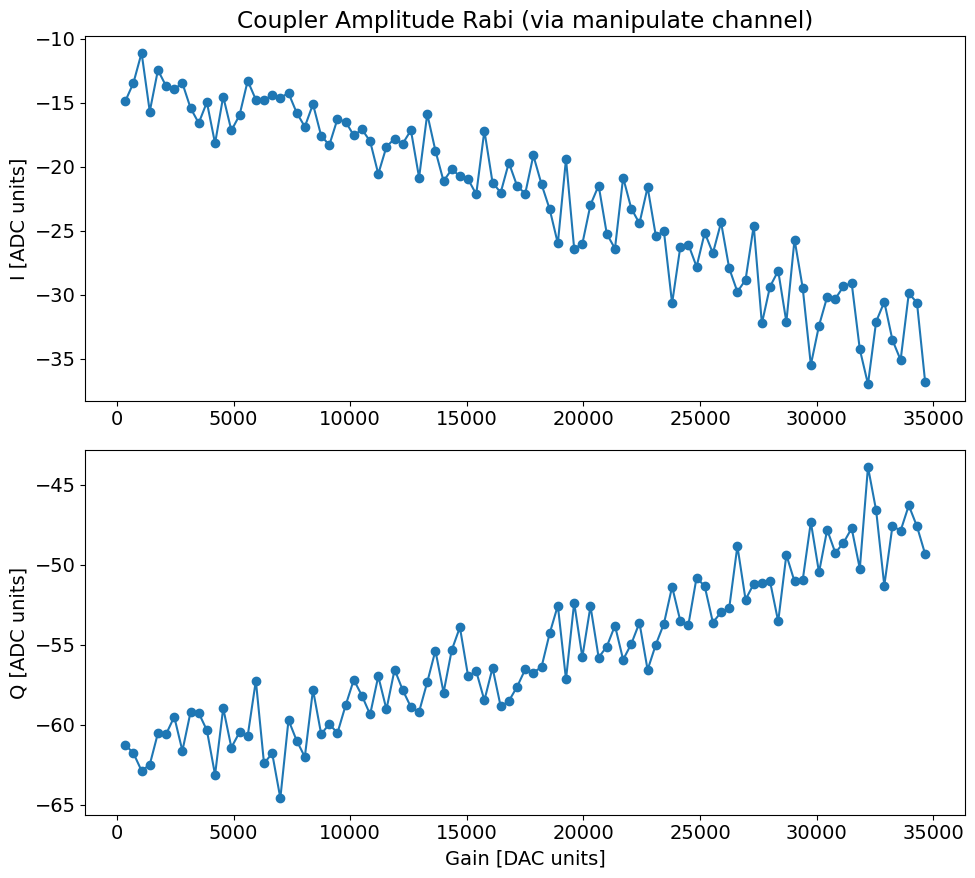

In [24]:
# 4. Execute
coupler_rabi_expt = coupler_rabi_runner.execute(
    start=0,
    step=350,
    expts=101,
    pulse_type ='gauss',
    sigma=0.1,
    freq=f_coupler,     # MHz - coupler feature from pulse-probe
    # length=.8,        # us (const pulse)
    reps=400,
    rounds=1,
    go_kwargs=dict(analyze=False, display=False),
    # **active_reset_dict,
)

# If using queue, analyze/display manually
if USE_QUEUE:
    coupler_rabi_expt.analyze(fit=False)
    coupler_rabi_expt.display(fit=False)

In [17]:
coupler_rabi_expt.data.keys()

dict_keys(['xpts', 'avgi', 'avgq', 'amps', 'phases', 'fit_avgi', 'fit_avgq', 'fit_amps', 'fit_err_avgi', 'fit_err_avgq', 'fit_err_amps', 'pi_gain_avgi', 'hpi_gain_avgi', 'pi_gain_avgq', 'hpi_gain_avgq', 'pi_gain_amps', 'hpi_gain_amps'])

In [22]:
coupler_rabi_expt.data['avgi']

array([-14.51737162, -14.22160811, -14.52875676, -13.68640541,
       -13.89552027, -14.70559459, -15.13208108, -14.32251351,
       -11.94316216, -14.54864865, -15.08350676, -12.95963514,
       -16.87769595, -12.54941216, -14.81837162, -13.74677703,
       -12.51723649, -16.65377027, -16.17510811, -14.6742973 ,
       -19.73456757, -16.91964189, -16.88056757, -15.55987838,
       -15.32465541, -16.18711486, -17.69008784, -19.15795946,
       -15.546     , -15.11833108, -16.2345    , -16.86310135,
       -14.98907432, -17.47511486, -20.09584459, -20.86442568,
       -15.85913514, -16.13067568, -18.86404054, -19.02564865,
       -16.49794595, -16.77040541, -17.29722973, -19.58716216,
       -20.04146622, -19.86681757, -18.4444527 , -19.15570946,
       -21.05754054, -18.61396622, -17.82295946, -20.50910811,
       -22.75579054, -23.79673649, -20.20897297, -22.87320946,
       -25.12191216, -19.37902703, -23.33324324, -20.5222973 ,
       -23.21557432, -23.95067568, -24.63631081, -22.37

## 2D: coupler Rabi vs. drive frequency

Outer sweep is the coupler drive `freq` (MHz) via `SweepRunner` (one queued
job per frequency point). Inner sweep is the amplitude Rabi on `man_ch` at
that frequency. All other `cfg.expt` knobs default to `coupler_rabi_defaults`
unless overridden as kwargs to `.execute(...)`.

In [11]:
# SweepRunner: outer = drive freq, inner = amplitude Rabi
coupler_rabi_vs_freq_runner = SweepRunner(
    station=station,
    ExptClass=meas.AmplitudeRabiCouplerExperiment,
    default_expt_cfg=coupler_rabi_defaults,
    sweep_param='freq',
    job_client=client,
    use_queue=USE_QUEUE,
)

# Frequency window around the pulse-probe feature.
f_center = f_coupler
f_span = 50.0      # MHz (full span around center)
f_npts = 5

coupler_rabi_2d = coupler_rabi_vs_freq_runner.execute(
    sweep_start=f_center - f_span / 2,
    sweep_stop=f_center + f_span / 2,
    sweep_npts=f_npts,
    # Inner-sweep / per-point overrides (any coupler_rabi_defaults field):
    start=0,
    step=350,
    expts=101,
    length=0.5,        # us (const pulse)
    reps=200,
    rounds=1,
    # batch=True,      # submit all jobs at once (default: sequential)
)

Sweep: freq from 4069.615943858794 to 4119.615943858794 (5 pts)
  File: D:\experiments\260420_T2_AC_stark\data\00001_AmplitudeRabiCouplerExperiment_sweep.h5
  [1/5] freq=4069.6159 Job submitted: JOB-20260421-00086 (queue position: 1)
[WORKER] Loading AmplitudeRabiCouplerExperiment from experiments.single_qubit.amplitude_rabi_coupler
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260421-00086_AmplitudeRabiCouplerExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
100%|███████████████████████████████████| 20200/20200 [00:50<00:00, 399.28it/s]
Saving D:\experiments\260420_T2_AC_stark\data\JOB-20260421-00086_AmplitudeRabiCouplerExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260420_T2_AC_stark\expt_objs\JOB-20260421-00086_expt.pkl
  [2/5] freq=4082.1159 Job submitted: JOB-20260421-00087 (queue position: 1)
[WORKER] Loading AmplitudeRabiCouplerExper

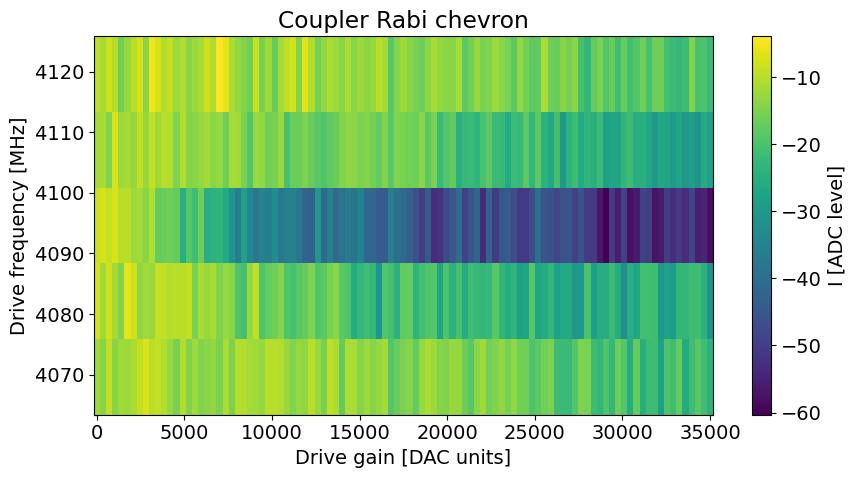

In [12]:
# Quick 2D heatmap of the sweep result
freqs_MHz = coupler_rabi_2d.data['freq_sweep']        # outer (y)
gains = coupler_rabi_2d.data['xpts'][0]               # inner (x), same each row
amps_2d = np.asarray(coupler_rabi_2d.data['avgi'])    # shape (n_freq, n_gain)

fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(gains, freqs_MHz, amps_2d, shading='auto', cmap='viridis')
ax.set_xlabel('Drive gain [DAC units]')
ax.set_ylabel('Drive frequency [MHz]')
ax.set_title('Coupler Rabi chevron')
fig.colorbar(pcm, ax=ax, label='I [ADC level]')
plt.tight_layout()
plt.show()

# Coupler length (time) Rabi (via manipulate channel)

Prep M1 in Fock |1>, play a pulse on the manipulate DAC at fixed freq and gain
with swept duration, swap |1> back to qubit |e>, then measure.

Defaults to `pulse_type='const'` (flat pulse of swept duration). Length is
swept in a Python-level loop (one compiled program per point), so `start` /
`step` / `expts` define the sweep in μs. `freq` and `gain` fall back to
`cfg.device.coupler.pulses.hpi` once snapshotted; until then pass them in
`cfg.expt` as below. `gain` here is typically the gain used in the amplitude
Rabi above.

In [26]:
# ============================================
# Coupler length Rabi
# prep M1 |1>  ->  pulse on man_ch (fixed freq+gain, swept duration)  ->  swap |1> -> |e>  ->  readout
# ============================================

# 1. Defaults
coupler_length_rabi_defaults = AttrDict(dict(
    # Length sweep [us]
    start=0.0,
    step=0.05,
    expts=101,           # spans 0 .. 5 us
    # Pulse envelope
    pulse_type='const',  # 'const' (flat, swept duration) or 'gauss' (sigma=length/4)
    # Pulse params (override cfg.device.coupler.pulses.hpi once that entry exists)
    freq=4100.0,         # MHz - same feature as the amplitude Rabi
    gain=5000,           # DAC - from the amplitude Rabi pi-gain fit
    # Averaging
    reps=200,
    rounds=1,
    # Mode / qubit selection
    qubits=[0],
    man_mode_no=1,
    # Optional user prepulse
    prepulse=False,
    pre_sweep_pulse=None,
    # Reset
    active_reset=False,
))


# 2. Optional postprocessor
def coupler_length_rabi_postproc(station, expt):
    """Fit + display the length-Rabi trace."""
    expt.analyze(fit=False)
    expt.display(fit=False)
    return None


# 3. Runner
coupler_length_rabi_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.LengthRabiCouplerExperiment,
    default_expt_cfg=coupler_length_rabi_defaults,
    postprocessor=coupler_length_rabi_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

Job submitted: JOB-20260421-00327 (queue position: 1)

[0.1s] Job JOB-20260421-00327: pending

[2.2s] Job JOB-20260421-00327: running
[WORKER] Loading LengthRabiCouplerExperiment from experiments.single_qubit.length_rabi_coupler
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260421-00327_LengthRabiCouplerExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 97%|███████████████████████████████████████▊ | 98/101 [01:52<00:03,  1.15s/it]
[123.5s] Job JOB-20260421-00327: completed
100%|████████████████████████████████████████| 101/101 [01:56<00:00,  1.15s/it]
Saving D:\experiments\260420_T2_AC_stark\data\JOB-20260421-00327_LengthRabiCouplerExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260420_T2_AC_stark\expt_objs\JOB-20260421-00327_expt.pkl

Job completed! Data: D:\experiments\260420_T2_AC_stark\data\JOB-20260421-00327_LengthRabiCouplerExperiment.

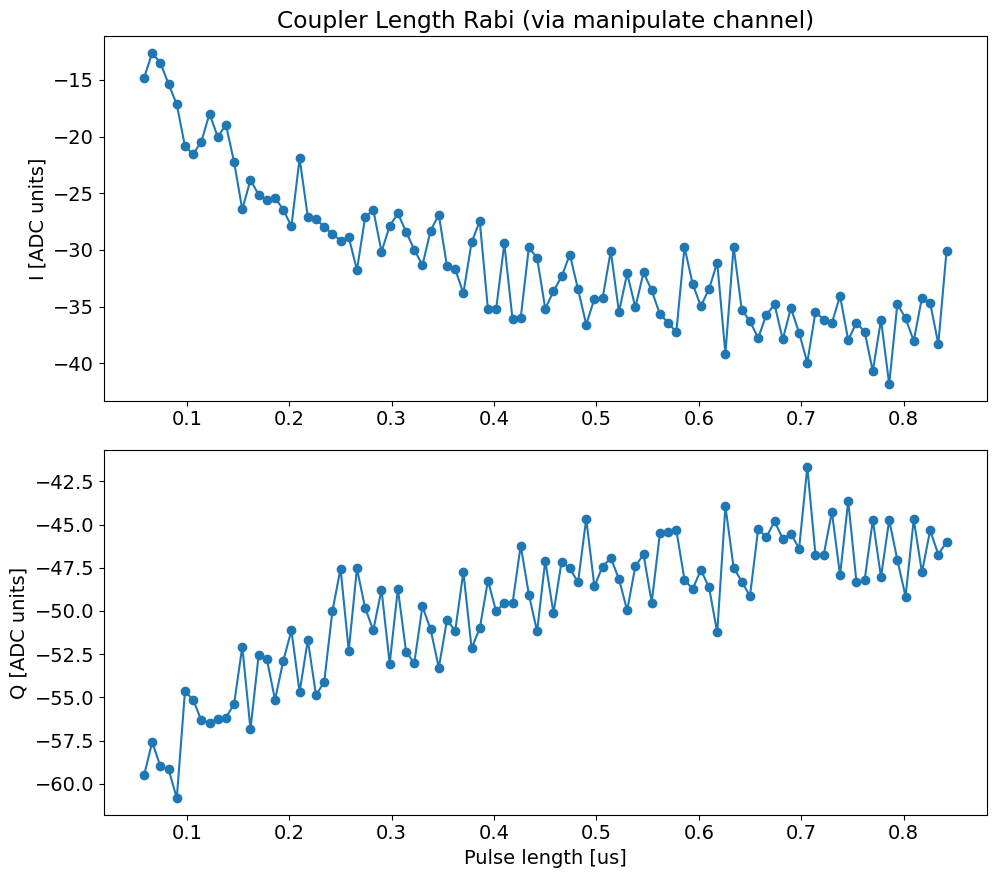

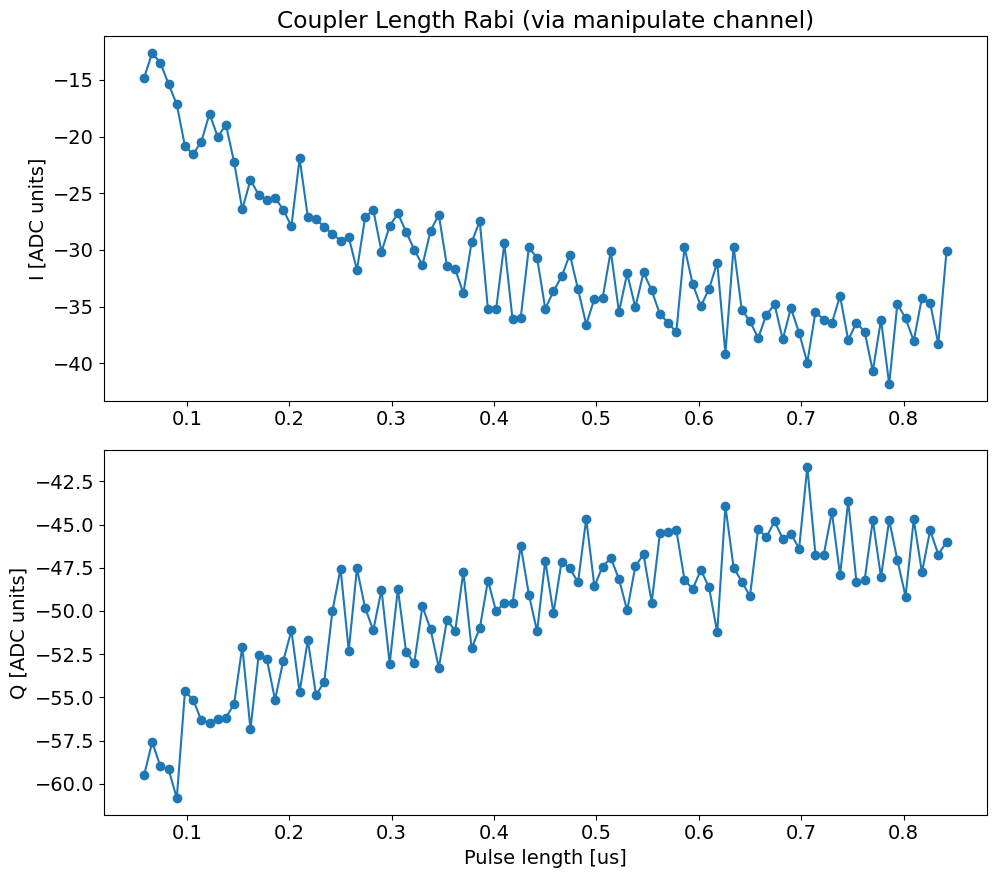

In [27]:
# 4. Execute
coupler_length_rabi_expt = coupler_length_rabi_runner.execute(
    # start=0.0,
    # step=0.008,
    # expts=101,
    # freq=f_coupler,  # MHz
    # gain=35000,       # DAC
    start=0.05,
    step=0.008,
    expts=101,
    pulse_type='gauss',
    freq=f_coupler,  # MHz
    gain=35000,       # DAC
    reps=400,
    rounds=1,
    go_kwargs=dict(analyze=False, display=False),
    # **active_reset_dict,
)

# If using queue, analyze/display manually
if USE_QUEUE:
    coupler_length_rabi_expt.analyze(fit=False)
    coupler_length_rabi_expt.display(fit=False)

# Coupler Ramsey (via manipulate channel)

Prep M1 in Fock |1>, play two pi/2 pulses on the manipulate DAC at a fixed
drive frequency with a swept wait tau in between (phase of the second pi/2
advances at `ramsey_freq`), swap |1> back to qubit |e>, then measure.

Defaults to `pulse_type='const'` (flat pi/2 of duration `length`); set
`pulse_type='gauss'` and pass `sigma` instead for a gaussian pi/2.

`freq`, `length`/`sigma`, and `gain` default to `cfg.device.coupler.pulses.hpi`
once that entry is snapshotted into the hardware config. Until then, pass
them explicitly in `cfg.expt` (as below) — `gain`/`length` here come from the
Rabi pi/2 calibration above.

In [ ]:
# ============================================
# Coupler Ramsey
# prep M1 |1>  ->  pi/2  ->  wait tau  ->  pi/2 (phase-advanced)  ->  swap |1> -> |e>  ->  readout
# ============================================

# 1. Defaults
coupler_ramsey_defaults = AttrDict(dict(
    # Wait-time sweep [us]
    start=0.02,
    step=0.1,
    expts=101,           # tau spans 0.02 .. ~10 us
    # Virtual detune used to advance the phase of pi/2 #2
    ramsey_freq=1.0,     # MHz (Nyquist: 0.5/step > ramsey_freq)
    # Pulse envelope
    pulse_type='const',  # 'gauss' (uses sigma) or 'const' (uses length)
    # Pulse params (override cfg.device.coupler.pulses.hpi once that entry exists)
    freq=4100.0,         # MHz - same feature as the Rabi
    length=0.5,          # us - flat const pi/2 duration (from Rabi pi/2 fit)
    gain=5000,           # DAC - pi/2 gain from the Rabi fit
    # Averaging
    reps=200,
    rounds=1,
    # Mode / qubit selection
    qubits=[0],
    man_mode_no=1,
    # Optional user prepulse
    prepulse=False,
    pre_sweep_pulse=None,
    # Reset
    active_reset=False,
))


# 2. Optional postprocessor
def coupler_ramsey_postproc(station, expt):
    """Fit + display the Ramsey trace."""
    expt.analyze(fit=False)
    expt.display(fit=False)
    return None


# 3. Runner
coupler_ramsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.RamseyCouplerExperiment,
    default_expt_cfg=coupler_ramsey_defaults,
    postprocessor=coupler_ramsey_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

Job submitted: JOB-20260421-00108 (queue position: 1)

[0.2s] Job JOB-20260421-00108: pending

[2.2s] Job JOB-20260421-00108: running
[WORKER] Loading RamseyCouplerExperiment from experiments.single_qubit.ramsey_coupler
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260421-00108_RamseyCouplerExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 97%|██████████████████████████████████ | 19656/20200 [00:49<00:01, 399.26it/s]
[58.5s] Job JOB-20260421-00108: completed
100%|███████████████████████████████████| 20200/20200 [00:50<00:00, 399.28it/s]
Saving D:\experiments\260420_T2_AC_stark\data\JOB-20260421-00108_RamseyCouplerExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260420_T2_AC_stark\expt_objs\JOB-20260421-00108_expt.pkl

Job completed! Data: D:\experiments\260420_T2_AC_stark\data\JOB-20260421-00108_RamseyCouplerExperiment.h5
Current coupler dri

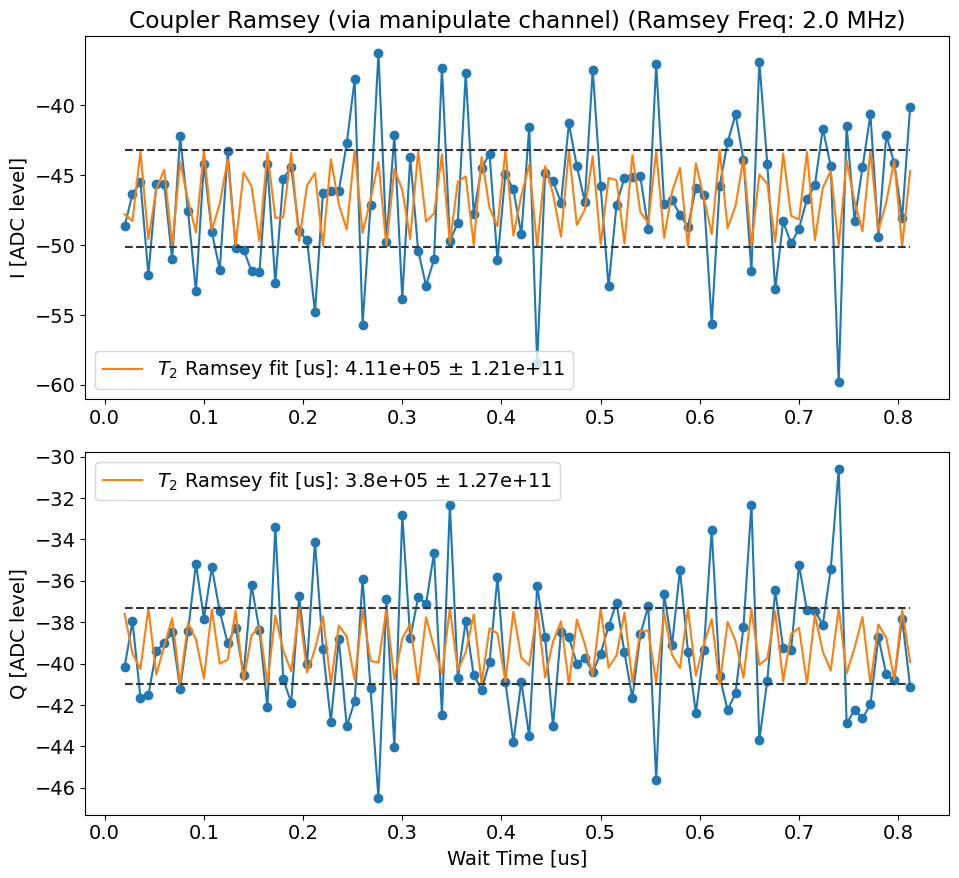

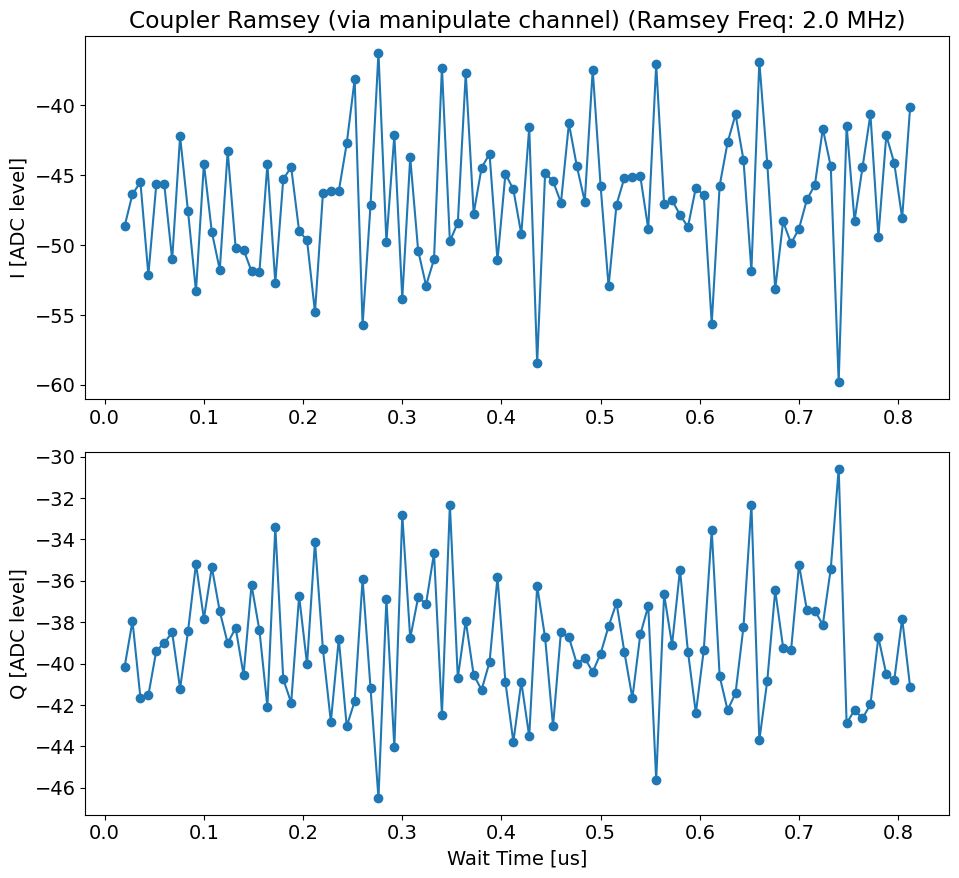

In [24]:
# 4. Execute
coupler_ramsey_expt = coupler_ramsey_runner.execute(
    start=0.02,
    step=0.008,
    expts=101,
    ramsey_freq=2.,
    freq=f_coupler,  # MHz - same feature as Rabi
    length=0.05,      # us - flat const pi/2 duration
    gain=35000,       # DAC - pi/2 gain from Rabi
    reps=200,
    rounds=1,
    go_kwargs=dict(analyze=False, display=False),
    # **active_reset_dict,
)

# If using queue, analyze/display manually
if USE_QUEUE:
    coupler_ramsey_expt.analyze(fit=False)
    coupler_ramsey_expt.display(fit=False)

In [30]:
coupler_t1_defaults = AttrDict(dict(
    start=0.0,
    step=0.1,         # us
    expts=100,        # tau spans 0..100 us
    reps=200,
    rounds=1,
    qubits=[0],
    man_mode_no=1,
    active_reset=False,
))




In [38]:
coupler_pulses = {
    'pi_ge': {
        'freq': [4093.367],
        # 'length': [0.5],
        'sigma': [0.05],
        # 'gain': [35000],
        'gain': [35000],
        'type': ['gauss']
  }
  }

station.hardware_cfg.device.coupler.pulses = coupler_pulses

Job submitted: JOB-20260421-00363 (queue position: 1)

[0.2s] Job JOB-20260421-00363: pending

[2.2s] Job JOB-20260421-00363: running
[WORKER] Loading T1CouplerExperiment from experiments.single_qubit.t1_coupler
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260421-00363_T1CouplerExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
Using coupler pi pulse params from cfg.device.coupler.pulses.pi_ge:
{'freq': [4093.367], 'sigma': [0.05], 'gain': [35000], 'type': ['gauss']}
Coupler pi pulse (gauss): freq=4093.367 MHz, sigma=0.05 us, gain=35000
100%|███████████████████████████████████| 20200/20200 [00:50<00:00, 398.58it/s]
Saving D:\experiments\260420_T2_AC_stark\data\JOB-20260421-00363_T1CouplerExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260420_T2_AC_stark\expt_objs\JOB-20260421-00363_expt.pkl

[59.3s] Job JOB-20260421-00363: completed

Job com

D:\python\multimode_expts\fitting\fitting.py:67: OptimizeWarning: Covariance of the parameters could not be estimated
  pOpt, pCov = sp.optimize.curve_fit(expfunc, xdata, ydata, p0=fitparams, maxfev=200000)
D:\python\multimode_expts\fitting\fitting.py:56: RuntimeWarning: overflow encountered in exp
  return y0 + yscale*np.exp(-(x-x0)/decay)


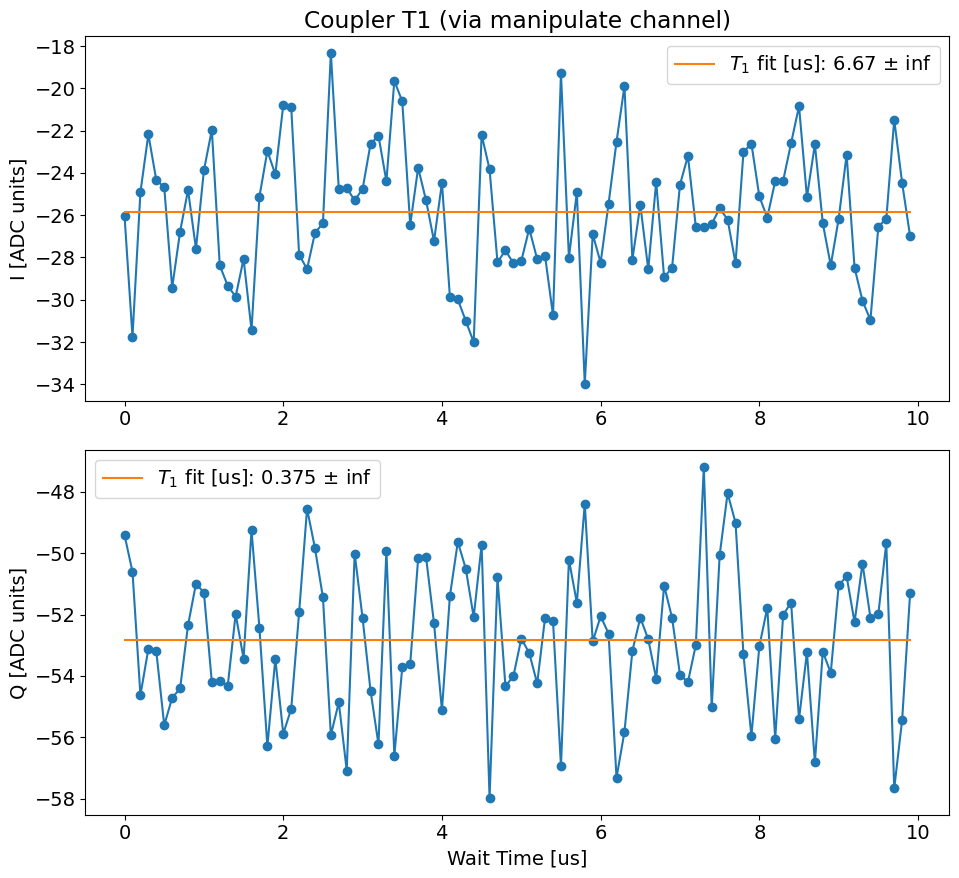

T1 from avgi [us]: 6.672700861718237
T1 from avgq [us]: 0.3750460019170574


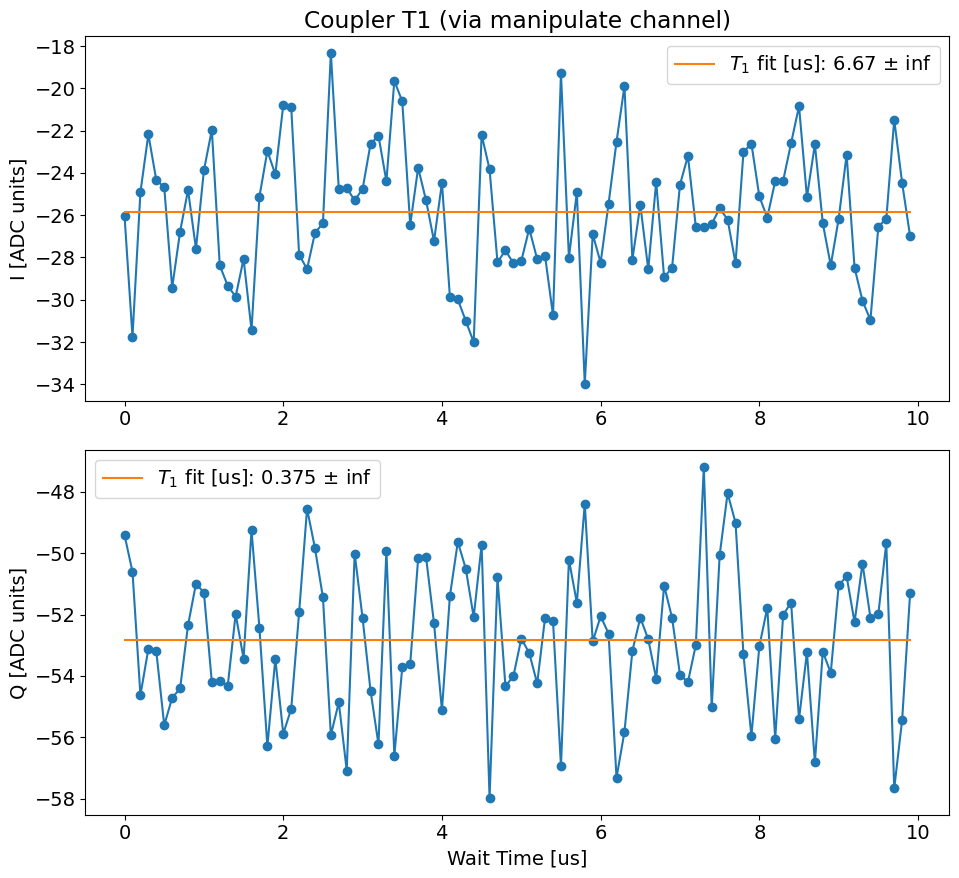

In [ ]:
coupler_t1_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.T1CouplerExperiment,
    default_expt_cfg=coupler_t1_defaults,
    postprocessor=lambda s, e: (e.analyze(fit=True), e.display(fit=True)),
    job_client=client,
    use_queue=USE_QUEUE,
)

coupler_t1_expt = coupler_t1_runner.execute(
    start=0.0, step=0.01, expts=101, reps=200, rounds=1,
    go_kwargs=dict(analyze=False, display=False),
)
if USE_QUEUE:
    coupler_t1_expt.analyze(fit=True)
    coupler_t1_expt.display(fit=True)

In [58]:
# station.preview_config_update()
station.snapshot_hardware_config(update_main=True)

[CONFIG] Reusing existing hardware_config version CFG-HW-20260421-00002
[CONFIG] Updated main hardware_config to CFG-HW-20260421-00002


'CFG-HW-20260421-00002'